<a href="https://colab.research.google.com/github/wahyuni111/business-decision-analysis/blob/main/notebooks_business_location_analysis_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **STUDY CASE:Menentukan lokasi strategis untuk membuka cabang restoran baru menggunakan data**

##Business Data Science Project
Pada project ini kita akan menganalisis data restoran untuk membantu menentukan lokasi bisnis yang potensial berdasarkan Pertimbangan data pelanggan, rating restoran, jenis makanan, dan layanan delivery.

#  Business Understanding

Sebuah perusahaan kuliner ingin membuka cabang restoran baru, namun belum mengetahui lokasi yang paling potensial.

Perusahaan perlu memahami:
- kota dengan aktivitas restoran tinggi,
- jenis makanan yang populer,
- tingkat kepuasan pelanggan,
- pengaruh layanan delivery,
- dan tingkat persaingan restoran.

Melalui analisis data ini, kita akan membantu perusahaan mengambil keputusan bisnis berdasarkan data.

**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#load dataset
df = pd.read_csv('/content/zomato.csv', encoding='latin1')

In [ ]:
#Menampilkan Dataset
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


**DATA UNDERSTANDING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
df.shape

(9551, 21)

In [ ]:
#Mengecek Missing value atau nilai data yang kosong
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


Terdapat data yang kosong pada kolom Cuisines sebanyak 9 data.

In [ ]:
#Mengecek Apakah ada data yang ter duplikat
df.duplicated().sum()

np.int64(0)

**DATA CLEANING**

In [ ]:
#Menampilkan data yang memiliki missing value pada kolom cuisines
df[df['Cuisines'].isnull()]

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
84,17284105,Cookie Shoppe,216,Albany,"115 N Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.154000,31.577200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,34
87,17284211,Pearly's Famous Country Cookng,216,Albany,"814 N Slappey Blvd, Albany, GA 31701",Albany,"Albany, Albany",-84.175900,31.588200,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,36
94,17284158,Jimmie's Hot Dogs,216,Albany,"204 S Jackson St, Albany, GA 31701",Albany,"Albany, Albany",-84.153400,31.575100,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,160
297,17374552,Corkscrew Cafe,216,Gainesville,"51 W Main St, Dahlonega, GA 30533",Dahlonega,"Dahlonega, Gainesville",-83.985800,34.531800,NaN,...,Dollar($),No,No,No,No,3,3.9,Yellow,Good,209
328,17501439,Dovetail,216,Macon,"543 Cherry St, Macon, GA 31201",Macon,"Macon, Macon",-83.627979,32.836410,NaN,...,Dollar($),No,No,No,No,3,3.8,Yellow,Good,102
346,17606621,HI Lite Bar & Lounge,216,Miller,"109 N Broadway Ave, Miller, SD 57362",Miller,"Miller, Miller",-98.989100,44.515800,NaN,...,Dollar($),No,No,No,No,1,3.4,Orange,Average,11
368,17059060,Hillstone,216,Orlando,"215 South Orlando Avenue, Winter Park, FL 32789",Winter Park,"Winter Park, Orlando",-81.365260,28.596682,NaN,...,Dollar($),No,No,No,No,3,4.4,Green,Very Good,1158
418,17142698,Leonard's Bakery,216,Rest of Hawaii,"933 Kapahulu Ave, Honolulu, HI 96816",Kaimuki,"Kaimuki, Rest of Hawaii",-157.813432,21.284586,NaN,...,Dollar($),No,No,No,No,1,4.7,Dark Green,Excellent,707
455,17616465,Tybee Island Social Club,216,Savannah,"1311 Butler Ave, Tybee Island, GA 31328",Tybee Island,"Tybee Island, Savannah",-80.848297,31.995810,NaN,...,Dollar($),No,No,No,No,1,3.9,Yellow,Good,309


NaN artinya data tidak memiliki isi atau kosong

In [ ]:
#Penanganan pada missing value
df = df.dropna(subset=['Cuisines'])

In [ ]:
#Memastikan Missing value sudah hilang
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,0


**EKPLORASI DATA MENGANALISA DATA**

In [ ]:
#Melihat Jumlah Kota Restoran dalam dataset
df['City'].nunique()

140

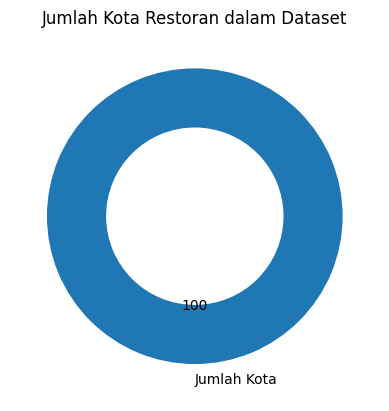

In [ ]:
import matplotlib.pyplot as plt

# Menghitung jumlah kota unik
jumlah_kota = df['City'].nunique()

# Data visualisasi
labels = ['Jumlah Kota']
sizes = [jumlah_kota]

# Membuat donut chart
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.0f',
    startangle=90,
    wedgeprops={'width':0.4}
)

# Judul
plt.title('Jumlah Kota Restoran dalam Dataset')

# Menampilkan visualisasi
plt.show()

In [ ]:
#Melihat Daftar Kota Restoran dalam dataset
df['City'].unique()

array(['Makati City', 'Mandaluyong City', 'Pasay City', 'Pasig City',
       'Quezon City', 'San Juan City', 'Santa Rosa', 'Tagaytay City',
       'Taguig City', 'Brasí_lia', 'Rio de Janeiro', 'Sí£o Paulo',
       'Albany', 'Armidale', 'Athens', 'Augusta', 'Balingup',
       'Beechworth', 'Boise', 'Cedar Rapids/Iowa City', 'Chatham-Kent',
       'Clatskanie', 'Cochrane', 'Columbus', 'Consort', 'Dalton',
       'Davenport', 'Des Moines', 'Dicky Beach', 'Dubuque',
       'East Ballina', 'Fernley', 'Flaxton', 'Forrest', 'Gainesville',
       'Hepburn Springs', 'Huskisson', 'Inverloch', 'Lakes Entrance',
       'Lakeview', 'Lincoln', 'Lorn', 'Macedon', 'Macon', 'Mayfield',
       'Mc Millan', 'Middleton Beach', 'Monroe', 'Montville',
       'Ojo Caliente', 'Orlando', 'Palm Cove', 'Paynesville', 'Penola',
       'Pensacola', 'Phillip Island', 'Pocatello', 'Potrero', 'Princeton',
       'Rest of Hawaii', 'Savannah', 'Singapore', 'Sioux City',
       'Tampa Bay', 'Tanunda', 'Trentham East', '

In [ ]:
#Melihat Kota yang paling banyak memiliki restoran
df['City'].value_counts().head(10)

,count
City,
New Delhi,5473
Gurgaon,1118
Noida,1080
Faridabad,251
Ghaziabad,25
Bhubaneshwar,21
Ahmedabad,21
Lucknow,21
Guwahati,21


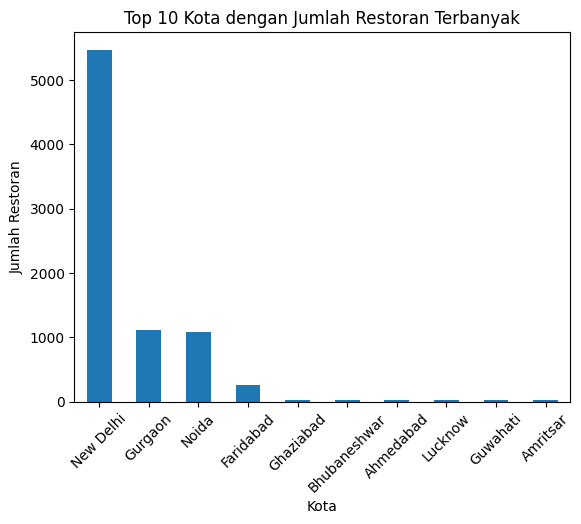

In [ ]:
#Visualisasi melihat kota dengan jumlah restoran terbanyak.
top_city = df['City'].value_counts().head(10)

top_city.plot(kind='bar')

plt.title('Top 10 Kota dengan Jumlah Restoran Terbanyak')
plt.xlabel('Kota')
plt.ylabel('Jumlah Restoran')

plt.xticks(rotation=45)

plt.show()

Kota dengan restoran terbanyak memang terlihat menarik, tetapi belum tentu menjadi lokasi terbaik karena persaingan bisnis juga lebih tinggi

In [ ]:
#Melihat Rata rata rating tiap kota
#Kota mana yang memiliki kualitas restoran terbaik
#tujuan nya untuk melihat kota dengan kepuasan pelanggan tertinggi
df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

,Aggregate rating
City,
Inner City,4.900000
Quezon City,4.800000
Makati City,4.650000
Pasig City,4.633333
Mandaluyong City,4.625000
Beechworth,4.600000
London,4.535000
Taguig City,4.525000
Lincoln,4.500000


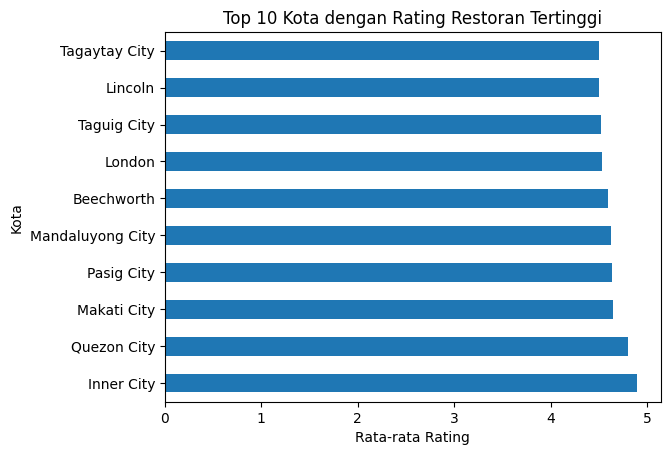

In [ ]:
#visualisasi
top_rating_city = df.groupby('City')['Aggregate rating'].mean().sort_values(ascending=False).head(10)

top_rating_city.plot(kind='barh')

plt.title('Top 10 Kota dengan Rating Restoran Tertinggi')
plt.xlabel('Rata-rata Rating')
plt.ylabel('Kota')

plt.show()

Apakah lebih baik membuka usaha di kota dengan pasar besar tetapi kompetisi tinggi,
atau kota dengan kualitas restoran tinggi dan pelanggan yang lebih puas?

In [ ]:
#Melihat Makanan yang paling popular atau diminatin
df['Cuisines'].value_counts().head(10)

,count
Cuisines,
North Indian,936
"North Indian, Chinese",511
Chinese,354
Fast Food,354
"North Indian, Mughlai",334
Cafe,299
Bakery,218
"North Indian, Mughlai, Chinese",197
"Bakery, Desserts",170


In [ ]:
df.groupby('Cuisines')['Aggregate rating'].mean()

,Aggregate rating
Cuisines,
Afghani,0.725
"Afghani, Mughlai, Chinese",0.000
"Afghani, North Indian",0.000
"Afghani, North Indian, Pakistani, Arabian",0.000
African,4.700
...,...
"Western, Asian, Cafe",4.200
"Western, Fusion, Fast Food",3.200
World Cuisine,4.900


In [ ]:
df.groupby('Cuisines')['Votes'].sum()

,Votes
Cuisines,
Afghani,39
"Afghani, Mughlai, Chinese",2
"Afghani, North Indian",0
"Afghani, North Indian, Pakistani, Arabian",3
African,373
...,...
"Western, Asian, Cafe",259
"Western, Fusion, Fast Food",32
World Cuisine,95


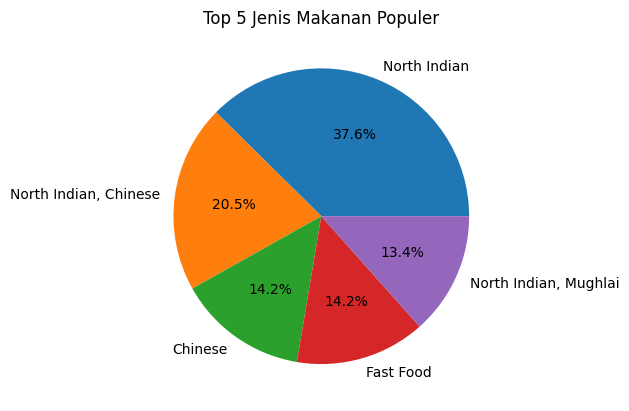

In [ ]:
#visualisasi
top_cuisines = df['Cuisines'].value_counts().head(5)

top_cuisines.plot(kind='pie', autopct='%1.1f%%')

plt.title('Top 5 Jenis Makanan Populer')

plt.ylabel('')

plt.show()

In [ ]:
#Melihat Jumlah Restoran yang menyediakan online delivery
#Tujuan nya :
#1. Memahami tren layanan digital pada binsis restoran
#2. Melihat seberapa banyak restoran yang telah menggunakan layanan delivery
df['Has Online delivery'].value_counts()

,count
Has Online delivery,
No,7091
Yes,2451


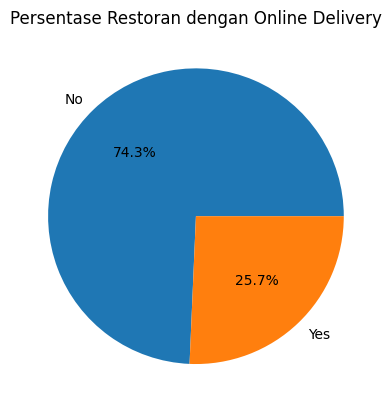

In [ ]:
delivery = df['Has Online delivery'].value_counts()

delivery.plot(kind='pie', autopct='%1.1f%%')

plt.title('Persentase Restoran dengan Online Delivery')

plt.ylabel('')

plt.show()

Hal ini dapat menunjukkan:

tidak semua restoran telah beradaptasi dengan layanan digital,
masih terdapat peluang bisnis bagi restoran yang menyediakan online delivery,
layanan delivery dapat menjadi nilai tambah dalam persaingan bisnis.

In [ ]:
#Melihat rata rata rating berdasarkan online delivery
#Tujuan : memahami hubungan antara layanan delivery dan kepuasan pelanggan.
df.groupby('Has Online delivery')['Aggregate rating'].mean()

,Aggregate rating
Has Online delivery,
No,2.463517
Yes,3.248837


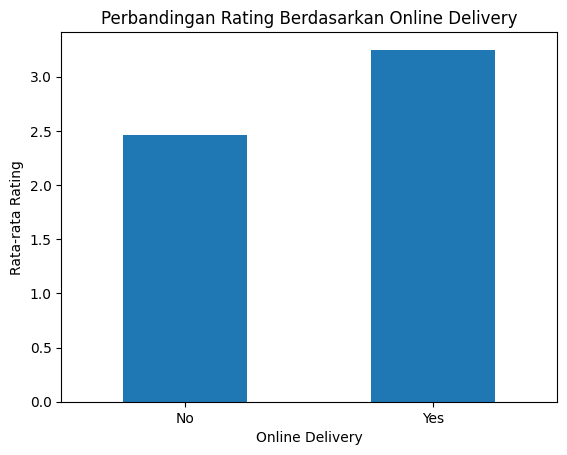

In [ ]:
delivery_rating = df.groupby('Has Online delivery')['Aggregate rating'].mean()

delivery_rating.plot(kind='bar')

plt.title('Perbandingan Rating Berdasarkan Online Delivery')
plt.xlabel('Online Delivery')
plt.ylabel('Rata-rata Rating')

plt.xticks(rotation=0)

plt.show()

Hal ini dapat menunjukkan bahwa:

pelanggan lebih menyukai restoran yang fleksibel dan mudah diakses,
layanan delivery dapat meningkatkan pengalaman pelanggan,
restoran dengan layanan online delivery memiliki nilai tambah dalam persaingan bisnis.

In [ ]:
#Melihat rata rata rating berdasarkan price range
#memahami apakah restoran dengan harga lebih mahal selalu memiliki kualitas lebih baik.
df.groupby('Price range')['Aggregate rating'].mean()

,Aggregate rating
Price range,
1,1.997476
2,2.941054
3,3.682633
4,3.817918


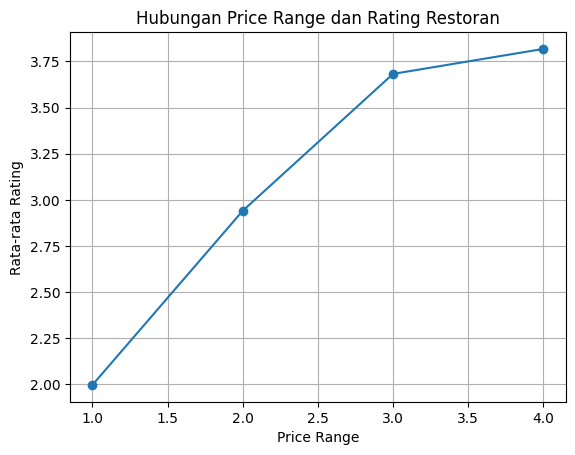

In [ ]:
price_rating = df.groupby('Price range')['Aggregate rating'].mean()

price_rating.plot(kind='line', marker='o')

plt.title('Hubungan Price Range dan Rating Restoran')
plt.xlabel('Price Range')
plt.ylabel('Rata-rata Rating')

plt.grid(True)

plt.show()

In [ ]:
#Melihat kota dengan jumlah votes terbanyak.
df.groupby('City')['Votes'].sum().sort_values(ascending=False).head(10)

,Votes
City,
New Delhi,628340
Gurgaon,132160
Noida,73488
Bangalore,56115
Kolkata,44593
Mumbai,29697
Chennai,27695
Tampa Bay,27407
Hyderabad,24135


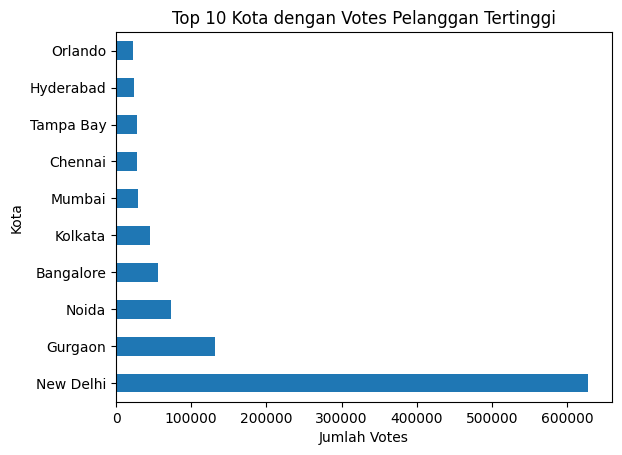

In [ ]:
top_votes_city = df.groupby('City')['Votes'].sum().sort_values(ascending=False).head(10)

top_votes_city.plot(kind='barh')

plt.title('Top 10 Kota dengan Votes Pelanggan Tertinggi')
plt.xlabel('Jumlah Votes')
plt.ylabel('Kota')

plt.show()

In [ ]:
#Menggabungkan Analisis Kota untuk membandingkan performa kota dan membantu menentukan lokasi bisnis potensial
city_analysis = df.groupby('City').agg({
    'Restaurant ID': 'count',
    'Aggregate rating': 'mean',
    'Votes': 'sum'
})

city_analysis.columns = ['Jumlah Restoran', 'Rata-rata Rating', 'Total Votes']

city_analysis.sort_values(by='Total Votes', ascending=False).head(10)

,Jumlah Restoran,Rata-rata Rating,Total Votes
City,,,
New Delhi,5473,2.438845,628340
Gurgaon,1118,2.651431,132160
Noida,1080,2.036204,73488
Bangalore,20,4.375000,56115
Kolkata,20,4.255000,44593
Mumbai,20,4.085000,29697
Chennai,20,4.315000,27695
Tampa Bay,20,4.410000,27407
Hyderabad,18,4.344444,24135


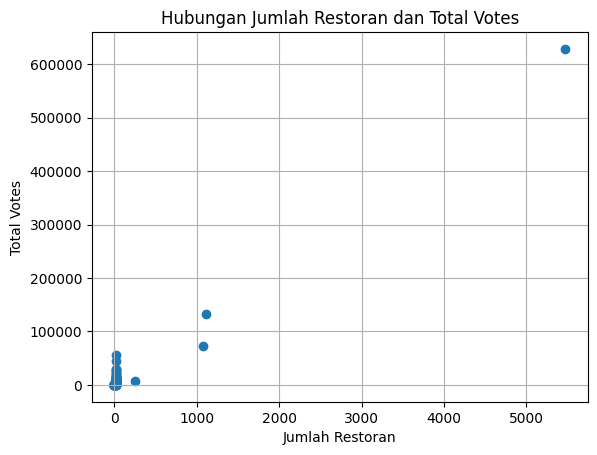

In [ ]:
plt.scatter(
    city_analysis['Jumlah Restoran'],
    city_analysis['Total Votes']
)

plt.title('Hubungan Jumlah Restoran dan Total Votes')
plt.xlabel('Jumlah Restoran')
plt.ylabel('Total Votes')

plt.grid(True)

plt.show()



1.   Analisis 1 jumlah restoran : new delhi pasar terbesar
2.   ANALISIS 2 :Rating kota: Kota dengan restoran banyak belum tentu rating tinggi.
3.   Analisis 3: Memahami preferensi pelanggan : Makanan North indian paling populer
4.   Analisis 4: memahami perilaku pelanggan modern : restoran jika memiliki delivery akan menambah value
5.   Analisis 5: Memahami hubungan harga dan kualitas: Restoran mahal cenderung punya ratig lebih tinggi  
6.   Analisis 6: Vote : new delhi punya engagement sangat tinggi
Decision making:




**INSIGHT:**
Berdasarkan hasil analisis data, New Delhi memiliki potensi pasar terbesar karena jumlah restoran dan aktivitas pelanggan sangat tinggi. Namun, tingkat persaingan bisnis di kota tersebut juga tinggi.

Sementara itu, kota seperti Bangalore dan Orlando menunjukkan kualitas pasar yang lebih baik dengan rating restoran tinggi dan engagement pelanggan yang cukup aktif.

Oleh karena itu, perusahaan dapat memilih strategi ekspansi berdasarkan tujuan bisnis:
- memilih New Delhi untuk menjangkau pasar besar,
- atau memilih kota dengan rating tinggi untuk membangun bisnis yang lebih stabil dan berkualitas.